# Atividade 3 -- Tópicos para Computação 1 -- 2026.1

- Escola Superior de Tecnologia
- Profa. Dra. Elloá B. Guedes (ebgcosta@uea.edu.br)
- www.elloaguedes.com
- github.com/elloa
- Data: 19 de março de 2026

## Descrição

A atividade consiste em construir uma rede neural convolucional para classificar o _Stanford Dogs Dataset_, um dataset com imagens de 120 raças de cachorro de todo o mundo e mais de 20 mil imagens para treino e teste.

## Material de Referência para Estudo

- http://vision.stanford.edu/aditya86/ImageNetDogs/


## Prazos importantes

- Data de entrega: 23/03/2026
- Modo de entrega: Google Classroom
- Estratégia de desenvolvimento: Quartetos (a interseção com grupos anteriores deve ter tamanho máximo igual a 2)

# Obtenção do dataset

- A tarefa a ser considerada é uma tarefa de classificação multiclasse
- A documentação oficial do dataset pode ser obtida aqui: http://vision.stanford.edu/aditya86/ImageNetDogs/
- Vamos usar essa versão do Kaggle em que as imagens e rótulos já estão organizados:
  https://www.kaggle.com/datasets/miljan/stanford-dogs-dataset-traintest
- Instale a API do Kaggle e faça o download do dataset usando Python
- Organize o nome das classes, retire o identificador "n[id]" do início das pastas

In [123]:
import os 
import csv
import random
from tqdm import tqdm
import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [ ]:
# Download Dataset
path = kagglehub.dataset_download("miljan/stanford-dogs-dataset-traintest")


print("Path to dataset files:", path)

c:\Users\melot\anaconda3\envs\tf_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Resuming download from 253755392 bytes (158786412 bytes left)...
Resuming download from https://www.kaggle.com/api/v1/datasets/download/miljan/stanford-dogs-dataset-traintest?dataset_version_number=1 (253755392/412541804) bytes left.


100%|██████████| 393M/393M [02:21<00:00, 1.13MB/s]

Extracting files...


Path to dataset files: C:\Users\melot\.cache\kagglehub\datasets\miljan\stanford-dogs-dataset-traintest\versions\1


In [ ]:
def rename_classes(path):

    for name in os.listdir(path):

        old_path = os.path.join(path, name)

        if os.path.isdir(old_path):

            new_name = name.split("-",1)[1]

            new_path = os.path.join(path, new_name)

            os.rename(old_path, new_path)


rename_classes(os.path.join(path,"cropped/train"))
rename_classes(os.path.join(path,"cropped/test"))

# Transformações na Entrada, Image Handler e Data Loader

- As imagens precisam ser padronizadas, vamos usar as dimensões 224x224 e a normalização das cores
- Transformação das Imagens: https://docs.pytorch.org/vision/0.8/transforms.html
- Operações: Redimensionamento, Para Tensor e Normalização ([-1,1] com média 0.5 e desvio padrão de 0.5)
- Criar um ImageHandler para cada pasta (treino/teste):
  - https://docs.pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html#torchvision.datasets.ImageFolder
- Para o treinamento: criar um Data loader com tamanho de lote igual a 32 e randomização
- https://docs.pytorch.org/docs/stable/data.html
- Para o teste: criar um Data loader com lote de tamanho igual a 1 e sem randomização

In [12]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )
])

In [13]:
train_dataset = ImageFolder(
    root=os.path.join(path,"cropped/train"),
    transform=transform
)

test_dataset = ImageFolder(
    root=os.path.join(path,"cropped/test"),
    transform=transform
)

In [14]:
print("Número de classes:", len(train_dataset.classes))
print(train_dataset.classes[:10])

Número de classes: 120
['Afghan_hound', 'African_hunting_dog', 'Airedale', 'American_Staffordshire_terrier', 'Appenzeller', 'Australian_terrier', 'Bedlington_terrier', 'Bernese_mountain_dog', 'Blenheim_spaniel', 'Border_collie']


In [58]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False
)

In [125]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


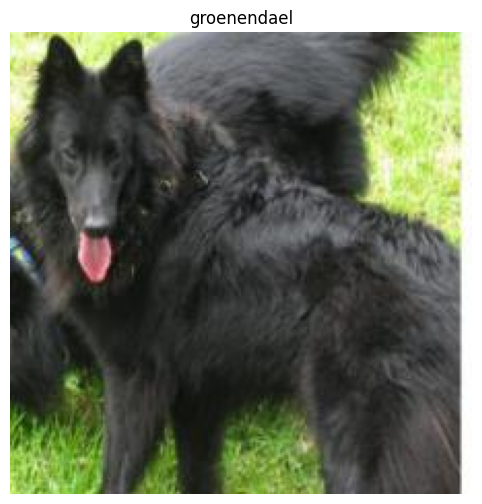

In [126]:
img = images[0]

# desfazer normalização
img = img * 0.5 + 0.5

plt.figure(figsize=(8,6))
plt.imshow(img.permute(1,2,0))
plt.title(train_dataset.classes[labels[0]])
plt.axis("off")
plt.show()

## Entendendo o Image Handler (dataset.ImageFolder) DataLoader

- Responda ao que se pede:
    1. Qual o papel do ImageHandler nesse contexto?
    2. E do DataLoader?
    3. Por que o tamanho do batch não pode ser todo o conjunto de dados?
    4. Por que o DataLoader do treinamento precisa de aleatoriedade?
    5. Por que o DataLoader do teste deve ter batch igual a 1 e sem aleatoriedade?

## Construindo sua primeira CNN: AlexNet

- Construa, camada a camada, a CNN AlexNet, vencedora do ImageNet 2012
- Arquitetura da AlexNet é dada a seguir:
1. Conv 1: 96 filtros de tamanho $11 \times 11$, com um stride (passo) de 4.
2. Max Pool 1: Redução espacial com janelas de $3 \times 3$ e stride 2.
3. Conv 2: 256 filtros de $5 \times 5$ com padding para manter a dimensão.
4. Max Pool 2: Outra redução de $3 \times 3$ com stride 2.
5. Conv 3, 4 e 5: Camadas convolucionais puras (sem pooling entre elas) com 384, 384 e 256 filtros de $3 \times 3$, respectivamente.
6. Max Pool 3: Última redução antes das camadas densas.
7. Camada de adaptação para classificação: Adaptive Average Pooling Bidimensional 6x6
8. FC 6 e 7: Duas camadas densas com 4096 neurônios cada, utilizando Dropout de 0.5 para reduzir o ovrfitting.
9. FC 8 (Saída): Camada final com ativação Softmax. Ajuste a camada de saída para o número de classes do problema encontrado.

### Sumário do Modelo

- Apresente o sumário do modelo, indicando quantos parâmetros ele possui e quantos destes são treináveis.


### Links Úteis

- https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
- https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.pooling.MaxPool2d.html
- https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.activation.ReLU.html
- https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.pooling.AdaptiveAvgPool2d.html
- https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.dropout.Dropout.html





In [ ]:
class AlexNet(nn.Module):

    def __init__(self, num_classes=120):
        super(AlexNet, self).__init__()

        # Camadas convolucionais
        self.features = nn.Sequential(

            # Conv1
            nn.Conv2d(3, 96, kernel_size=11, stride=4),
            nn.ReLU(inplace=True),

            # MaxPool1
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Conv2
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),

            # MaxPool2
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Conv3
            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Conv4
            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Conv5
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # MaxPool3
            nn.MaxPool2d(kernel_size=3, stride=2)
        )

        # Adaptative pooling
        self.avgpool = nn.AdaptiveAvgPool2d((6,6))

        # Camada totalmente conectada
        self.classifier = nn.Sequential(

            nn.Dropout(p=0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),

            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),

            nn.Linear(4096, num_classes)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.avgpool(x)

        x = torch.flatten(x, 1)

        x = self.classifier(x)

        return x

## Configuração do Treino

- 120 épocas
- Otimizador: Mini-batch SGD com Momentum (tal qual no paper original da AlexNet)
- Zere os gradientes do otimizador
- Lotes de 32
- Taxa de aprendizado: 10^(-3)
- Momentum: 0.9
- Função de perda: Entropia Cruzada Categórica
- Caso tenha disponibilidade, acelere o treino com GPU

### Monitorando o Treinamento

- Ao longo das épocas, armazene o loss e a acurácia no treino em um arquivo csv

#### Links Úteis

- https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html
- https://docs.pytorch.org/docs/stable/generated/torch.optim.SGD.html

In [63]:
EPOCHS = 120
LEARNING_RATE = 1e-3
MOMENTUM = 0.9
WHEIGHT_DECAY = 5e-4

In [64]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


print("Device:", device)

Device: cuda


In [ ]:
model = AlexNet(num_classes=120).to(device)

criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=LEARNING_RATE,
    momentum=MOMENTUM
    #weight_decay=WHEIGHT_DECAY
)

In [ ]:
with open("training_log.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["epoch","loss","accuracy"])

In [ ]:
epochs = EPOCHS
best_acc = 0

os.makedirs("models", exist_ok=True)

for epoch in range(epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for batch_idx, (images, labels) in enumerate(pbar):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        acc = correct / total

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{acc:.4f}",
            "batch": f"{batch_idx+1}/{len(train_loader)}"
        })

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total

    print(f"Epoch {epoch+1}/{epochs}  Loss:{epoch_loss:.4f}  Acc:{epoch_acc:.4f}")

    # salvar métricas
    with open("training_log.csv","a",newline="") as f:
        writer = csv.writer(f)
        writer.writerow([epoch+1, epoch_loss, epoch_acc])

    # salvar melhor modelo
    if epoch_acc > best_acc:
        best_acc = epoch_acc
        torch.save(model.state_dict(), "models/best_model.pth")

## Métricas do Treinamento

- Elabore um gráfico com a função de perda ao longo das épocas
- Elabore um gráfico com a acurácia do conjunto de treino ao longo das épocas
- Responda: O treino foi eficiente?

In [53]:
df = pd.read_csv("training_log.csv")

print(df.head())

   epoch      loss  accuracy
0      1  4.787707  0.008167
1      2  4.787598  0.007750
2      3  4.787545  0.008750
3      4  4.787358  0.008667
4      5  4.787205  0.009417


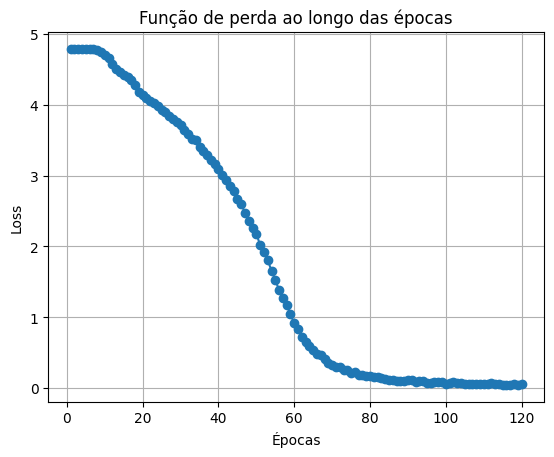

In [54]:
plt.figure()

plt.plot(df["epoch"], df["loss"], marker="o")

plt.title("Função de perda ao longo das épocas")
plt.xlabel("Épocas")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

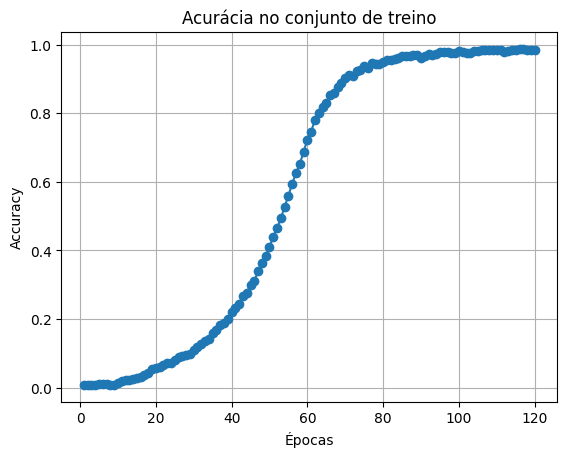

In [55]:
plt.figure()

plt.plot(df["epoch"], df["accuracy"], marker="o")

plt.title("Acurácia no conjunto de treino")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

### Persista o modelo

- Salvar o modelo com os pesos após o aprendizado é uma estratégia importante para posteriormente utilizá-lo para inferência ou para análises comparativas
- Nesta atividade, salve o modelo em disco e recupere-o para efetuar a avaliação no conjunto de testes

In [70]:
model.load_state_dict(torch.load("models/best_model.pth"))
model.eval()

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
    (2): ReLU(inp

## Avaliação do Modelo

- Faça as inferências do modelo para o conjunto de testes e cálcule as métricas para uma tarefa de classificação multiclasse
- Elabore uma matriz de confusão
- Escolha três exemplos aleatórios do conjunto de testes, exiba-as e mostre também as top-3 probabilidades de classificação

In [56]:
model.eval()

all_preds = []
all_labels = []

In [59]:
with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [60]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="macro")
recall = recall_score(all_labels, all_preds, average="macro")
f1 = f1_score(all_labels, all_preds, average="macro")

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.25198135198135196
Precision: 0.2479011187038058
Recall: 0.2482328350368245
F1-score: 0.23764436785326162


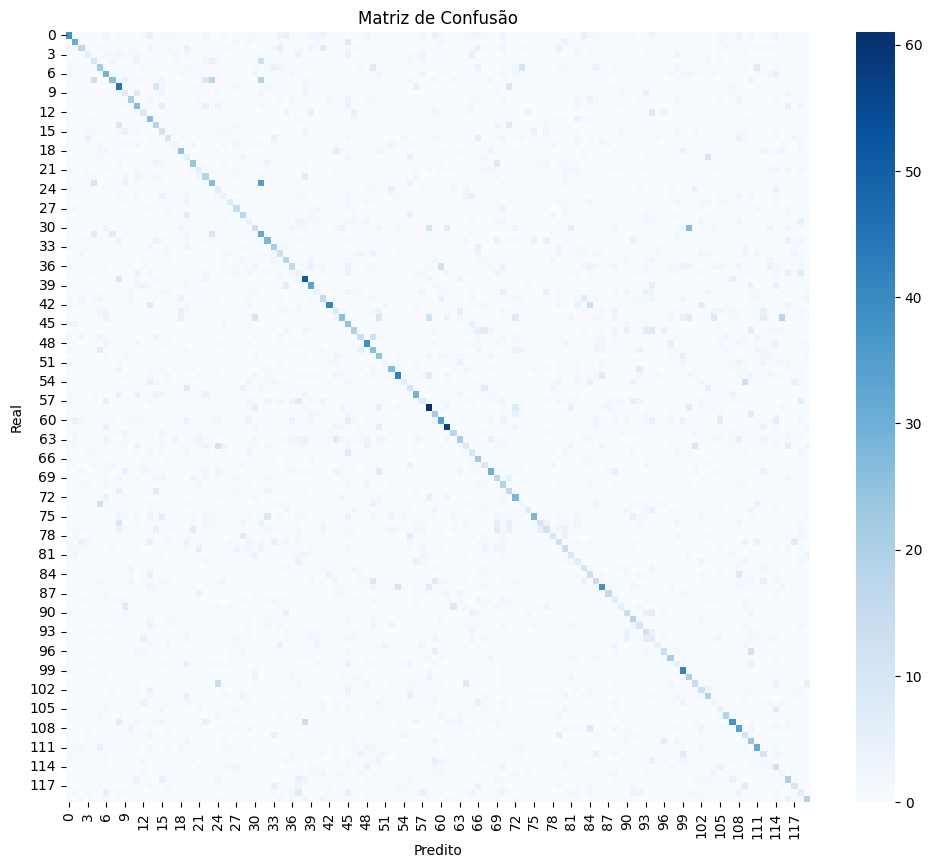

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12,10))

sns.heatmap(cm, cmap="Blues")

plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")

plt.show()

In [87]:
def denormalize(img):

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    img = img * std + mean
    return img.clamp(0,1)

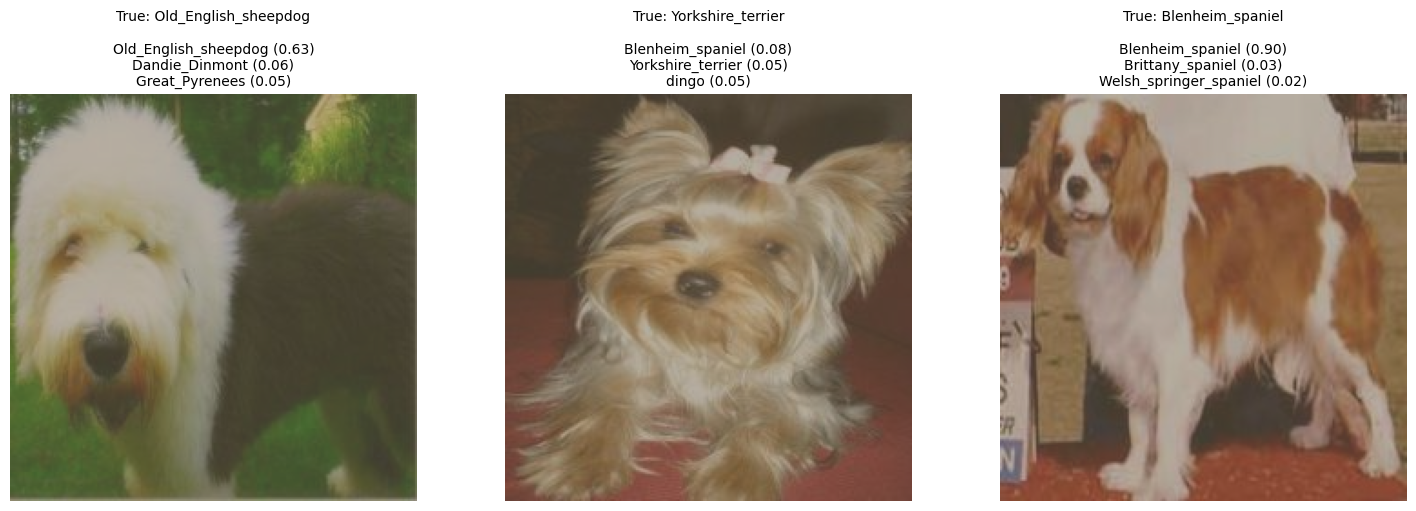

In [122]:
model.eval()

classes = test_dataset.classes

indices = random.sample(range(len(test_dataset)), 3)

fig, axes = plt.subplots(1, 3, figsize=(15,5))

for ax, idx in zip(axes, indices):

    image, label = test_dataset[idx]

    input_img = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_img)

    probs = torch.softmax(output, dim=1)

    top3_prob, top3_idx = torch.topk(probs, 3)

    top3_prob = top3_prob.cpu().numpy()[0]
    top3_idx = top3_idx.cpu().numpy()[0]

    pred_classes = [classes[i] for i in top3_idx]
    true_class = classes[label]

    img_show = denormalize(image)

    ax.imshow(img_show.permute(1,2,0))
    ax.axis("off")

    title = f"True: {true_class}\n\n"
    title += "\n".join([
        f"{pred_classes[i]} ({top3_prob[i]:.2f})"
        for i in range(3)
    ])

    ax.set_title(title, fontsize=10)

plt.tight_layout()
plt.show()

## Parecer Avaliativo

- Elabore um parecer sobre o desempenho do modelo, elencando vantagens e limitações
- Faça a sugestão de três estratégias a serem incorporadas no modelo ou em seu treinamento para que haja melhoria de desempenho